In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

print("Librerías cargadas ✅")

Librerías cargadas ✅


In [4]:
df = pd.read_csv('../data/telco_churn.csv')

# Corregir TotalCharges (viene como string)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Eliminar columna ID
df = df.drop(columns=['customerID'])

print(f"Shape: {df.shape}")
print(f"Nulos restantes: {df.isnull().sum().sum()}")

Shape: (7043, 20)
Nulos restantes: 0


In [5]:
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

# Columnas binarias Yes/No
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling',
               'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
               'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0, 'No phone service': 0, 'No internet service': 0})

# Columnas con más categorías
df = pd.get_dummies(df, columns=['gender', 'InternetService', 'Contract', 'PaymentMethod'])

print(f"Shape final: {df.shape}")
df.head(2)

Shape final: (7043, 28)


,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,...,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,0,1,0,0,0,1,0,0,...,True,False,False,True,False,False,False,False,True,False
1,0,0,0,34,1,0,1,0,1,0,...,True,False,False,False,True,False,False,False,False,True


In [6]:
X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"Train original: {y_train.value_counts().to_dict()}")
print(f"Train con SMOTE: {pd.Series(y_train_sm).value_counts().to_dict()}")
print(f"Test: {y_test.value_counts().to_dict()}")

Train original: {0: 4139, 1: 1495}
Train con SMOTE: {0: 4139, 1: 4139}
Test: {0: 1035, 1: 374}


In [7]:
model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

model.fit(X_train_sm, y_train_sm)
print("Modelo entrenado ✅")

Modelo entrenado ✅


=== MÉTRICAS ===

              precision    recall  f1-score   support

    No Churn       0.86      0.83      0.85      1035
       Churn       0.57      0.61      0.59       374

    accuracy                           0.78      1409
   macro avg       0.71      0.72      0.72      1409
weighted avg       0.78      0.78      0.78      1409

AUC-ROC: 0.8411


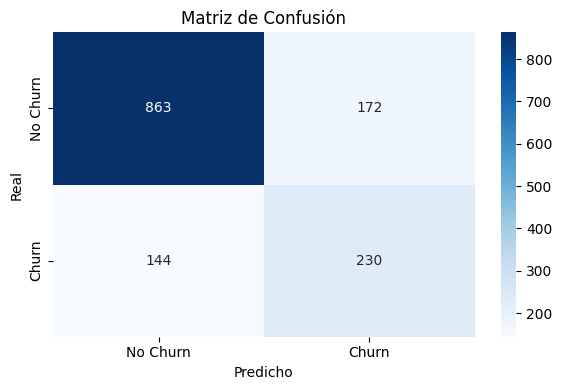

In [8]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("=== MÉTRICAS ===\n")
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))
print(f"AUC-ROC: {roc_auc_score(y_test, y_proba):.4f}")

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Matriz de Confusión')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.tight_layout()
plt.savefig('../data/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

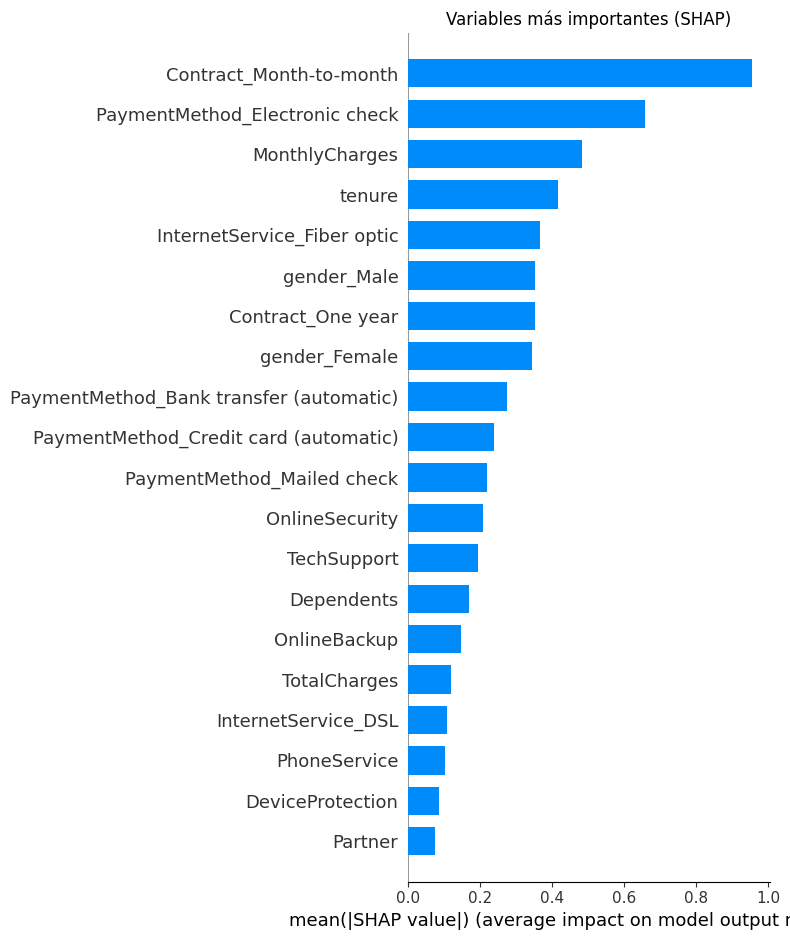

In [9]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

plt.figure()
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("Variables más importantes (SHAP)")
plt.tight_layout()
plt.savefig('../data/shap_importancia.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
joblib.dump(model, '../data/modelo_churn.pkl')
joblib.dump(list(X.columns), '../data/features.pkl')
print("Modelo guardado en data/modelo_churn.pkl ✅")
print("Features guardadas en data/features.pkl ✅")

Modelo guardado en data/modelo_churn.pkl ✅
Features guardadas en data/features.pkl ✅


In [11]:
features = joblib.load('../data/features.pkl')
print(features)

['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'gender_Female', 'gender_Male', 'InternetService_DSL', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_Month-to-month', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Bank transfer (automatic)', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']
